### **Iterative Prompt Developent**
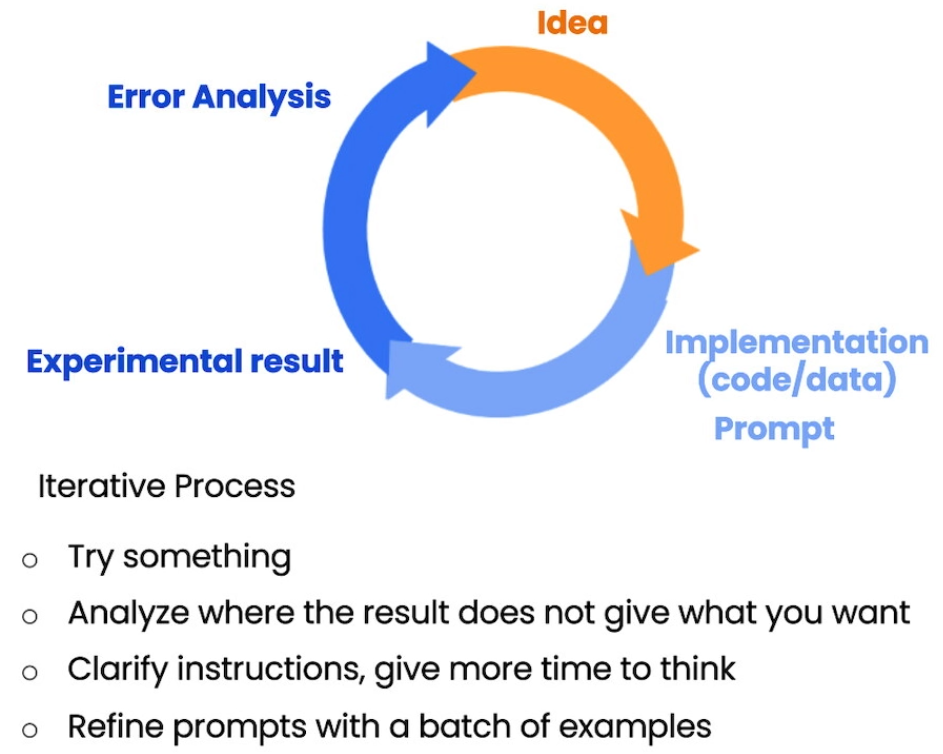

In [6]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI
from pprint import pprint


_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-3.5-turbo'
chat = ChatOpenAI(model = llm_model)

#### **Generate a marketing product description from a product fact sheet**

In [7]:
fact_sheet_chair = '''
OVERVIEW
- Part of a beautiful family of mid-century inspired office furniture, 
including filing cabinets, desks, bookcases, meeting tables, and more.
- Several options of shell color and base finishes.
- Available with plastic back and front upholstery (SWC-100) 
or full upholstery (SWC-110) in 10 fabric and 6 leather options.
- Base finish options are: stainless steel, matte black, 
gloss white, or chrome.
- Chair is available with or without armrests.
- Suitable for home or business settings.
- Qualified for contract use.

CONSTRUCTION
- 5-wheel plastic coated aluminum base.
- Pneumatic chair adjust for easy raise/lower action.

DIMENSIONS
- WIDTH 53 CM | 20.87’
- DEPTH 51 CM | 20.08’
- HEIGHT 80 CM | 31.50’
- SEAT HEIGHT 44 CM | 17.32’
- SEAT DEPTH 41 CM | 16.14’

OPTIONS
- Soft or hard-floor caster options.
- Two choices of seat foam densities: 
 medium (1.8 lb/ft3) or high (2.8 lb/ft3)
- Armless or 8 position PU armrests 

MATERIALS
SHELL BASE GLIDER
- Cast Aluminum with modified nylon PA6/PA66 coating.
- Shell thickness: 10 mm.
SEAT
- HD36 foam

COUNTRY OF ORIGIN
- Italy
'''

prompt = f'''
Your task is to help a marketing team create a 
description for a retail website of a product based 
on a technical fact sheet.

Write a product description based on the information 
provided in the technical specifications delimited by 
triple backticks.

Technical specifications: ```{fact_sheet_chair}```
'''

response = chat.invoke(prompt)
pprint(response.content)

('Introducing the sleek and versatile SWC-100/SWC-110 office chair, part of '
 "our stunning mid-century inspired furniture collection. Whether you're "
 'looking to upgrade your home office or elevate your business setting, this '
 'chair is the perfect choice.\n'
 '\n'
 'With a range of shell color and base finish options to choose from, you can '
 'customize the chair to suit your style. The SWC-100/SWC-110 is available '
 'with either plastic back and front upholstery or full upholstery in a '
 'variety of fabric and leather choices.\n'
 '\n'
 'Constructed with a durable 5-wheel plastic coated aluminum base and '
 'featuring a pneumatic chair adjust for easy height adjustment, this chair is '
 'as functional as it is stylish. The dimensions of the chair are perfect for '
 'any space, and with options for soft or hard-floor casters and different '
 'seat foam densities, you can customize your comfort level.\n'
 '\n'
 'Designed and crafted in Italy, the SWC-100/SWC-110 exudes quality

#### **Issue 1: The text is too long**
Limit the number of words/sentences/characters.

In [9]:
prompt = f'''
Your task is to help a marketing team create a 
description for a retail website of a product based 
on a technical fact sheet.

Write a product description based on the information 
provided in the technical specifications delimited by 
triple backticks.

Use at most 50 words.

Technical specifications: ```{fact_sheet_chair}```
'''

response = chat.invoke(prompt)
pprint(response.content)
print (len(response.content.split(' ')))

('Introducing our versatile and stylish mid-century office chair. Customizable '
 'with various shell colors, base finishes, and upholstery options. Featuring '
 'a durable 5-wheel base and pneumatic height adjustment. Perfect for home or '
 'business use, designed in Italy for quality assurance. Elevate your '
 'workspace with this modern essential.')
46


#### **Issue 2. Text focuses on the wrong details**
Ask it to focus on the aspects that are relevant to the intended audience.

In [10]:
prompt = f'''
Your task is to help a marketing team create a 
description for a retail website of a product based 
on a technical fact sheet.

Write a product description based on the information 
provided in the technical specifications delimited by 
triple backticks.

The description is intended for furniture retailers, 
so should be technical in nature and focus on the 
materials the product is constructed from.

Use at most 50 words.

Technical specifications: ```{fact_sheet_chair}```
'''

response = chat.invoke(prompt)
pprint(response.content)

('Introducing our versatile mid-century inspired office chair, crafted with '
 'quality materials for durability and style. The shell base glider is made of '
 'cast aluminum with a modified nylon coating, while the seat features HD36 '
 'foam for comfort. Choose from a variety of colors and finishes to suit any '
 'home or business setting. Made in Italy.')


In [11]:
prompt = f'''
Your task is to help a marketing team create a 
description for a retail website of a product based 
on a technical fact sheet.

Write a product description based on the information 
provided in the technical specifications delimited by 
triple backticks.

The description is intended for furniture retailers, 
so should be technical in nature and focus on the 
materials the product is constructed from.

At the end of the description, include every 7-character 
Product ID in the technical specification.

Use at most 50 words.

Technical specifications: ```{fact_sheet_chair}```
'''

response = chat.invoke(prompt)
pprint(response.content)

('Introducing our versatile and stylish office chair, part of a modern '
 'mid-century furniture collection. Choose from a variety of shell colors and '
 'base finishes to suit your style. This chair is constructed with a durable '
 'aluminum base and high-density foam seat for ultimate comfort. Perfect for '
 'any home or business space. \n'
 '\n'
 'Product ID: SWC-100, SWC-110')


#### **Issue 3. Description needs a table of dimensions**
Ask it to extract information and organize it in a table.

In [12]:
prompt = f'''
Your task is to help a marketing team create a 
description for a retail website of a product based 
on a technical fact sheet.

Write a product description based on the information 
provided in the technical specifications delimited by 
triple backticks.

The description is intended for furniture retailers, 
so should be technical in nature and focus on the 
materials the product is constructed from.

At the end of the description, include every 7-character 
Product ID in the technical specification.

After the description, include a table that gives the 
product's dimensions. The table should have two columns.
In the first column include the name of the dimension. 
In the second column include the measurements in inches only.

Give the table the title 'Product Dimensions'.

Format everything as HTML that can be used in a website. 
Place the description in a <div> element.

Technical specifications: ```{fact_sheet_chair}```
'''

response = chat.invoke(prompt)
pprint(response.content)

('<div>\n'
 '<p>Introducing the newest addition to our collection of mid-century inspired '
 'office furniture: the versatile and stylish office chair. Crafted with '
 'attention to detail and quality, this chair is part of a beautiful family of '
 'furniture that includes filing cabinets, desks, bookcases, meeting tables, '
 'and more.</p>\n'
 '\n'
 '<p>The chair offers several options for customization, with choices of shell '
 'color and base finishes to suit your decor. You can also choose between '
 'plastic back and front upholstery or full upholstery in a variety of fabric '
 'and leather options. The base finish options include stainless steel, matte '
 'black, gloss white, or chrome, giving you the freedom to design the chair '
 'that best fits your space.</p>\n'
 '\n'
 '<p>Constructed with a 5-wheel plastic-coated aluminum base and equipped with '
 'a pneumatic chair adjust for easy raise/lower action, this chair is not only '
 'stylish but also functional. It is suitable for

#### **Load Python libraries to view HTML**

In [15]:
from IPython.display import display, HTML

display(HTML(response.content))

WIDTH,53 CM | 20.87”
DEPTH,51 CM | 20.08”
HEIGHT,80 CM | 31.50”
SEAT HEIGHT,44 CM | 17.32”
SEAT DEPTH,41 CM | 16.14”
